# **Decision Tree & Ensemble Learning** (Sesi 15-16, 27 April 2026)

Fadhlan Nur Rachman (2802491960)

Data Dictionary :
- survival:	Survival	0 = No, 1 = Yes
- pclass:	Ticket class	1 = 1st, 2 = 2nd, 3 = 3rd
- sex:	Sex
- Age:	Age in years
- sibsp	# of siblings / spouses aboard the Titanic
- parch	# of parents / children aboard the Titanic
- ticket:	Ticket number
- fare:	Passenger fare
- cabin:	Cabin number
- embarked:	Port of Embarkation	C = Cherbourg, Q = Queenstown, S = Southampton

In [1]:
# Import Dataset

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

train_data = pd.read_csv('titanic/train.csv')

In [2]:
train_data.shape

(891, 12)

**Interpretasi cell diatas**:  
terdapat data train sebanyak (891 baris dan 12 fitur) termasuk dengan 1 fitur target


In [3]:
# Preview Dataset
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Drop Unnecessary Columns
cols_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']

train_data = train_data.drop(columns=cols_to_drop)
train_data.shape

(891, 8)

**Interpretasi cell diatas**:  
PassengerId, Name, Ticket, dan Cabin dihapus karena variable ini bertipe string dengan unique value yang tinggi atau memiliki banyak data hilang, sehingga data tersebut tidak bisa memberikan pola statistik

# Exploratory Data Analysis

In [5]:
# Check head
train_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


**Interpretasi cell diatas**:  
Hasil data train setelah menghapus variable PassengerId, Name, Ticket, dan Cabin


In [6]:
# Identifying Data Structure

train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


**Interpretasi cell diatas**:  
cek informasi dari data train terdapat info tipedata dari setiap variable ada 2 float, 4 integer, dan 2 object atau kategorikal data. serta terdapat banyaknya baris yang memiliki isi dari setiap variable nya. dan disini kita bisa mengetahui data lengkap seluruhnya terisi ada 891 dan jika ada variable yang tidak 891 berarti ada missing value


In [7]:
# Summary Statistics for Numerical Columns

train_data.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Interpretasi cell diatas**:  
terdapat hasil statistik data numerical yang bisa menunjukkan distribusi serta kesimpulan dari setiap data nya dan bisa jadi insight untuk kita seperti contoh "rata-rata umur penumpang adalah sekitar 29.7 tahun" lalu ada "tarif(Fare) memiliki standar deviasi yang sangat tinggi 49.69 yang menunjukan adanya kesenjangan harga tiket yang lebar" dan berbagai informasi menarik lainnya


In [8]:
# Summary Statistics for Categorical Columns

train_data.describe(include=['O'])

,Sex,Embarked
count,891,889
unique,2,3
top,male,S
freq,577,644


**Interpretasi cell diatas**:  
terdapat hasil statistik data kategorikal yang menunjukan distribusi jumlah penumpang berdasarkan jenis kelamin(Sex) dan pelabuhan keberangkatan(Embarked). dan ada juga mayoritas seperti penumpang banyak yang naik dari pelabuhan 'S' (Southampton) dan jenis kelamin terbanyak jatuh kepada lelaki dengan frekuensi muncul sebanyak 577

In [9]:
# Percentage of Missing Values

missing_summary = pd.DataFrame({
    'Missing Count': train_data.isnull().sum(),
    'Missing Percentage(%)': (train_data.isnull().mean() * 100).round(2)
})
missing_summary

,Missing Count,Missing Percentage(%)
Survived,0,0.00
Pclass,0,0.00
Sex,0,0.00
Age,177,19.87
SibSp,0,0.00
Parch,0,0.00
Fare,0,0.00
Embarked,2,0.22


**Interpretasi cell diatas**:  
Melihat sebuah missing value yang lebih lengkap dimana ternyata terdapat sebuah persentase yang menunjukan 19.86% data umur(Age) ada baris yang hilang serta 0.22% pelabuhan keberangkatan(Embarked) ada baris yang hilang juga

In [10]:
# Cross Tabulation

sex_embarked_ct = pd.crosstab(train_data['Sex'], train_data['Embarked'], dropna=False)

sex_embarked_ct

Embarked,C,Q,S,NaN
Sex,,,,
female,73,36,203,2
male,95,41,441,0


**Interpretasi cell diatas**:  
Menunjukkan distribusi jumlah penumpang berdasarkan jenis kelamin dan pelabuhan keberangkatan. Mayoritas penumpang naik dari pelabuhan 'S' (Southampton) dan sebagai contoh informasi "di pelabuhan southampton terdapat 203 penumpang perempuan yang naik ke kapal"

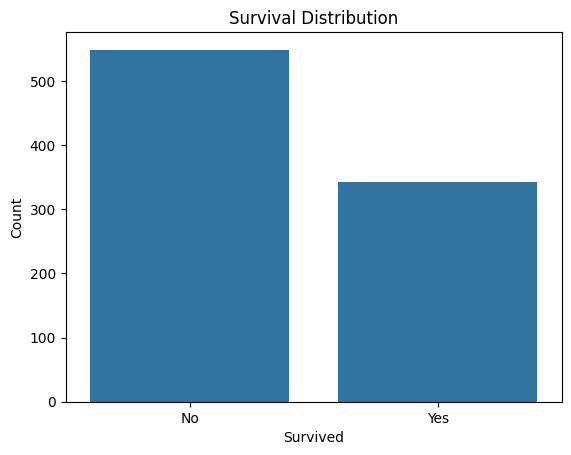

In [11]:
# Bar Plot Survival Distribution

import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Survived', data=train_data)
plt.title('Survival Distribution')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()

**Interpretasi cell diatas**:  
Terlihat Data target tidak seimbang. jumlah penumpang yang tidak selamat(survived = 0) jauh lebih banyak daripada yang selamat(survived = 1)

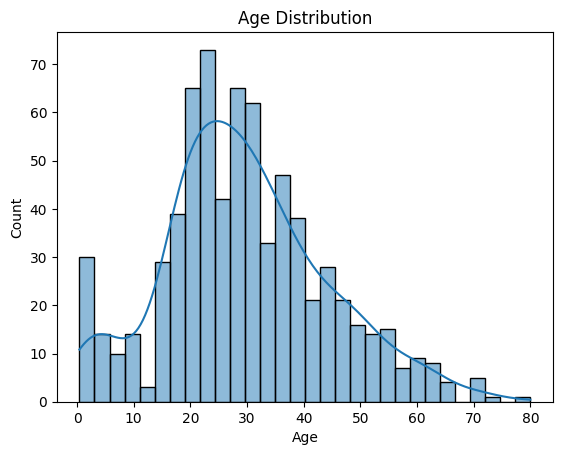

In [12]:
# Age Distribution

sns.histplot(train_data['Age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.show()

**Interpretasi cell diatas**:  
Distribusi histogram umur mendekati kurva normal namus sedikit miring ke kanan(right-skewed), dengan konsentrasi penumpang terbesar berada diusia produktif(20-40 tahun).

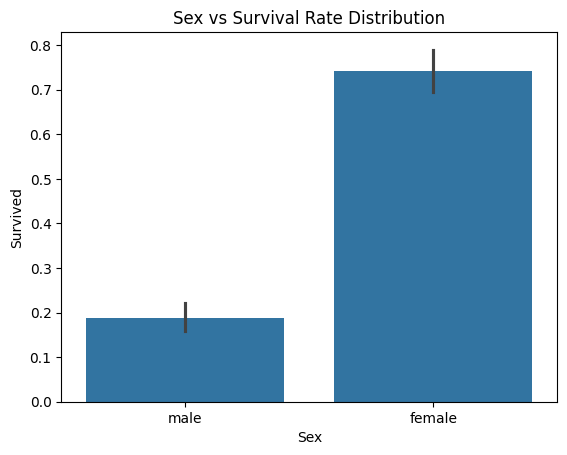

In [13]:
# Sex vs Survival Rate Distribution
sns.barplot(x='Sex', y='Survived', data=train_data)
plt.title('Sex vs Survival Rate Distribution')
plt.show()

**Interpretasi cell diatas**:  
Terdapat perbedaan drastis pada tingkat keselamatan. Perempuan memiliki peluang selamat yang jauh lebih tinggi dibandingkan laki-laki. Ini membuktikan juga aturan wanita didahulukan saat evakuasi.

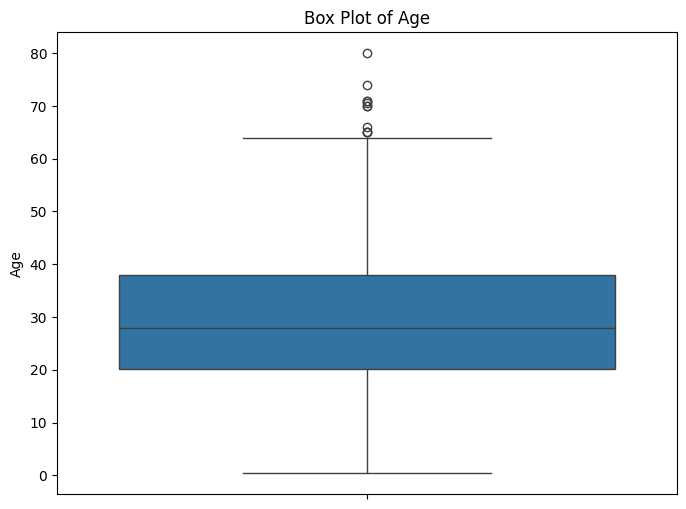

In [14]:
# Box Plot Age

plt.figure(figsize=(8, 6))
sns.boxplot(y=train_data['Age'])
plt.title('Box Plot of Age')
plt.ylabel('Age')
plt.show()

**Interpretasi cell diatas**:  
Terdapat beberapa outlier pada fitur umur (age) menunjukan bahwa ada beberapa data unik yaitu ada lansia dengan umur diatas 65 tahun yang menaiki kapal titanic ini

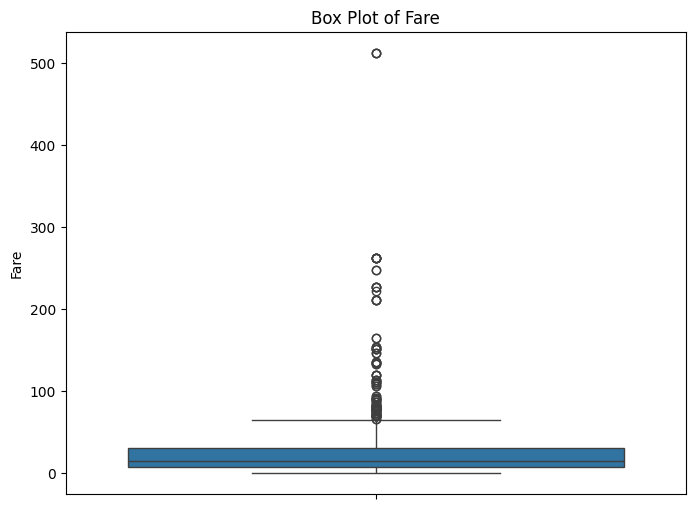

In [15]:
# Box Plot Fare

plt.figure(figsize=(8, 6))
sns.boxplot(y=train_data['Fare'])
plt.title('Box Plot of Fare')
plt.ylabel('Fare')
plt.show()

**Interpretasi cell diatas**:  
Terdapat beberapa outlier pada fitur tarif(fare) dimana kebanyakan orang mempunyai tarif tiket direntang harga 0 hingga 80, dan ada beberapa orang yang membeli tarif tiket diatas harga 80

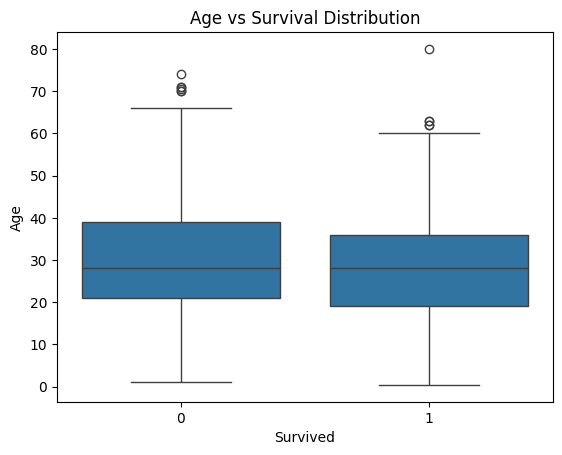

In [16]:
# age vs survived distribution
sns.boxplot(x='Survived', y='Age', data=train_data)
plt.title('Age vs Survival Distribution')
plt.xlabel('Survived')
plt.ylabel('Age')
plt.show()

#### Interpretasi cell diatas :
Rentang umur pada kedua kelompok (selamat/tidak selamat) serupa. Namun, pada kelompok selamat, terdapat variasi umur yang lebih lebar di bagian bawah (anak-anak), menunjukkan prioritas keselamatan pada usia muda. lalu kita bisa lihat juga di boxplot terdapat beberapa outlier yang keluar

In [17]:
# Correlation-Based Feature Selection

import numpy as np
numerical_cols = train_data.select_dtypes(include=[np.number]).columns
corr = train_data[numerical_cols].corr()
corr

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


**Interpretasi cell diatas**:  
Melihat beberapa corelasi antar fitur menggunakan tabel dan cukup sulit dibaca

In [18]:
# Creating an Interactive Heatmap

import plotly.express as px
fig = px.imshow(corr, text_auto='.2f', aspect='auto', color_continuous_scale='RdBu_r', title='Interactive Correlation Matrix')

fig.update_layout(width=800, height=700)
fig.show()

**Interpretasi cell diatas**:  
Melihat beberapa korelasi antar fitur menggunakan heatmap dimana kita bisa melihat dengan jelas secara detail juga korelasi antar fiturnya seperti tarif(fare) dan kelas penumpang(pclass) memiliki korelasi tinggi bertolak belakang atau minus

In [19]:
# Top Correlated Features with 'Survived'

top_corr = corr['Survived'].abs().sort_values(ascending=False).head(6)
top_corr

Survived    1.000000
Pclass      0.338481
Fare        0.257307
Parch       0.081629
Age         0.077221
SibSp       0.035322
Name: Survived, dtype: float64

**Interpretasi cell diatas**:<br>
Top fitur secara ascending yang berkorelasi dengan fitur target(Survived)

# Data Preprocessing

In [20]:
# Drop Column with 50% Missing Values

missing_ratio = train_data.isnull().mean()
cols_to_keep = missing_ratio[missing_ratio <= 0.5].index
train_data = train_data[cols_to_keep]
train_data.shape

(891, 8)

**Interpretasi cell diatas**:<br>
Menghapus fitur/kolom yang mempunyai missing value diatas 50%, namun karena di dataset ini yang mempunyai missing value terbanyak hanya 19.87% jadi tidak ada yang terkena drop missing value code ini

In [21]:
# Age Imputation with Mean

train_data['Age'] = train_data['Age'].fillna(train_data['Age'].mean())

**Interpretasi cell diatas**:<br>
Mengisi missing value variable umur(Age) menggunakan rata-rata(Mean) karena umur adalah data numerik yang distribusi nya cukup padat

In [22]:
# Embarked with Mode

train_data['Embarked'] = train_data['Embarked'].fillna(train_data['Embarked'].mode()[0])

**Interpretasi cell diatas**:<br>
Mengisi missing value variable Pelabuhan Keberangkatan(Embarked) karena hanya 2 data hilang ktia menggunakan modus karena umur adalah data kategorikal, maka diisi dengan nilai yang paling sering muncul.

In [23]:
# Re check Missing Values

missing_summary = pd.DataFrame({
    'Missing Count': train_data.isnull().sum(),
    'Missing Percentage(%)': (train_data.isnull().mean() * 100).round(2)
})
missing_summary

,Missing Count,Missing Percentage(%)
Survived,0,0.0
Pclass,0,0.0
Sex,0,0.0
Age,0,0.0
SibSp,0,0.0
Parch,0,0.0
Fare,0,0.0
Embarked,0,0.0


**Interpretasi cell diatas**:<br>
Setelah proses mengisi missing value bisa dilihat sekarang sudah tidak ada lagi data yang hilang atau tidak terisi

In [24]:
# Label Encoding

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in ['Sex', 'Embarked']:
    train_data[col] = le.fit_transform(train_data[col])

**Interpretasi cell diatas**:<br>
Mengubah data kategorikal menjadi angka agar bisa dibaca algoritma dan komputer, dimana contoh: (Male/Female) menjadi 0 dan 1

In [25]:
train_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


**Interpretasi cell diatas**:<br>
Konfirmasi data kategorikal sudah berubah menjadi numerical yang sudah bisa dibaca oleh komputer

In [26]:
# Seperate Target Class

x = train_data.drop('Survived', axis=1)
y = train_data['Survived']

**Interpretasi cell diatas**:<br>
Memisahkan fitur dependen(y) dan independen(x) lalu mendeklarasikannya di variable baru

In [27]:
# Split dataset into training and testing 70:30

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42, stratify=y)

**Interpretasi cell diatas**:  
Membagi data Training (Data latih) dan data Validation (Data Validasi) dengan rasio 70:30 dan diacak secara konsisten dan juga mengelompokan sesuai bobot kelasnya agar tidak imbalance class

In [28]:
# Normalization with Standard Scaler

from sklearn.preprocessing import StandardScaler

scale_cols = ['Age', 'Fare']

scaler = StandardScaler()

x_train[scale_cols] = scaler.fit_transform(x_train[scale_cols])
x_test[scale_cols] = scaler.transform(x_test[scale_cols])

**Interpretasi cell diatas**: 
transformasi atau standarisasi kolom umur(age) dan tarif(fare) memiliki skala yang sangat tinggi dengan data yang lainnya dan standarisasi mengubah data sehingga memiliki rata-rata = 0 dan standar deviasi = 1, lalu standar scaler(z-score) ini memiliki rentang dari -1 hingga 1

In [29]:
x_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
748,1,1,-0.842505,1,0,0.465738,2
45,3,1,-0.021501,0,0,-0.478269,2
28,3,0,-0.021501,0,0,-0.481848,1
633,1,1,-0.021501,0,0,-0.646954,2
403,3,1,-0.151884,1,0,-0.314823,2


**Interpretasi cell diatas**: 
hasil transformasi atau standarisasi variable umur(age) dan tarif(fare) supaya rentang nya sama

# Model Development

In [30]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(
    max_depth=5, # Kedalaman pohon
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced', # Menangani Imabalance Class
    random_state=42
)
model_dt.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,20
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


**Interpretasi cell diatas**:
Decision Tree adalah algoritma machine learning dan model prediksi yang terstruktur seperti pohon untuk memecahkan masalah klasifikasi dan regresi. Menggunakan parameter kedalaman pohon yang dibatasi agar tidak ovefit, pembentukan cabang tree yang di cegah, serta weight balancing untuk menangani imabalance class

In [31]:
# Majority Voting
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import VotingClassifier

estimators_mv = [
    ('dt', DecisionTreeClassifier(
        max_depth=5, min_samples_leaf=10,
        class_weight='balanced', random_state=42)),
    ('lr', LogisticRegression(
        C=1.0, max_iter=1000,
        class_weight='balanced', random_state=42)),
    ('nb', GaussianNB())
]

model_mv = VotingClassifier(estimators=estimators_mv, voting='soft')
model_mv.fit(x_train, y_train)

,estimators,"[('dt', ...), ('lr', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,10


**Interpretasi cell diatas**:
Soft Voting menggabungkan **probabilitas** prediksi dari Decision Tree, Logistic Regression, dan Naive Bayes lalu memilih kelas dengan rata-rata probabilitas tertinggi. Soft Voting umumnya lebih akurat dari Hard Voting karena memperhitungkan tingkat keyakinan tiap model, dan mendukung prediksi probability untuk menghitung ROC-AUC.

In [32]:
# Bagging
from sklearn.ensemble import BaggingClassifier

base_dt_bag = DecisionTreeClassifier(
    max_depth=8,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)

model_bag = BaggingClassifier(
    estimator=base_dt_bag,
    n_estimators=200,
    max_samples=0.8,
    max_features=0.8,
    random_state=42,
    n_jobs=-1
)
model_bag.fit(x_train, y_train)

,estimator,DecisionTreeC...ndom_state=42)
,n_estimators,200
,max_samples,0.8
,max_features,0.8
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,-1
,random_state,42
,verbose,0


**Interpretasi cell diatas**:
Bagging melatih 200 Decision Tree secara paralel pada bootstrap sample. Parameter kunci nya terdapat:
- max_depth: lebih dalam dari DT tunggal karena bagging sudah mengurangi variance
- max_samples dan max_features : memaksa setiap pohon belajar dari subset data dan fitur yang berbeda, meningkatkan diversitas antar pohon
- weight balancing: base estimator tetap sensitif terhadap imbalance class
- n_jobs: memanfaatkan seluruh core CPU untuk training paralel

In [33]:
# Boosting (AdaBoost)
from sklearn.ensemble import AdaBoostClassifier

model_boost = AdaBoostClassifier(
    n_estimators=200,
    learning_rate=0.5,
    random_state=42
)
model_boost.fit(x_train, y_train)

,estimator,None
,n_estimators,200
,learning_rate,0.5
,algorithm,'deprecated'
,random_state,42


**Interpretasi cell diatas**: AdaBoost adalah algoritma ensemble learning yang meningkatkan performa model machine learning dengan menggabungkan beberapa klasifikator lemah, decision tree/stump, menjadi satu klasifikator yang kuat. Dengan parameter :

- n_estimators=200: lebih banyak weak learner memberikan konvergensi lebih baik
- learning_rate=0.5: kontribusi tiap learner. Nilai lebih kecil dari default (1.0) memperlambat learning sehingga model lebih stabil dan kurang overfit.

In [34]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    max_features='sqrt',
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
model_rf.fit(x_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


**Interpretasi cell diatas**:
Random Forest adalah algoritma machine learning ensemble yang menggabungkan hasil dari beberapa decision tree (pohon keputusan) untuk mencapai prediksi yang lebih akurat dan stabil. dengan parameter:

- n_estimators=300: lebih banyak pohon memberikan estimasi lebih stabil
- max_depth=10: mencegah pohon terlalu dalam yang bisa overfit
- max_features='sqrt': pada setiap split hanya mempertimbangkan sqrt(7) fitur, memaksa diversitas antar pohon dan mengurangi korelasi
- min_samples_leaf=5: setiap leaf harus memiliki minimal 5 data (anti-overfit)
- class_weight='balanced': otomatis menyesuaikan bobot sesuai proporsi kelas
- n_jobs=-1: training paralel di semua core CPU

In [35]:
# Stacking
# Base learners (level-0): DT, Bagging, AdaBoost yang sudah dituning
# Meta-learner (level-1) : Logistic Regression dengan class_weight='balanced'
from sklearn.ensemble import StackingClassifier

base_learners = [
    ('dt', DecisionTreeClassifier(
        max_depth=5, min_samples_leaf=10,
        class_weight='balanced', random_state=42)),
    ('bag', BaggingClassifier(
        estimator=DecisionTreeClassifier(
            max_depth=8, min_samples_leaf=5,
            class_weight='balanced', random_state=42),
        n_estimators=100, max_samples=0.8,
        max_features=0.8, random_state=42)),
    ('boost', AdaBoostClassifier(
        n_estimators=100, learning_rate=0.5, random_state=42))
]

meta_learner = LogisticRegression(
    C=1.0, max_iter=1000,
    class_weight='balanced',
    random_state=42
)

model_stack = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=5,
    passthrough=False
)
model_stack.fit(x_train, y_train)

,estimators,"[('dt', ...), ('bag', ...), ...]"
,final_estimator,LogisticRegre...ndom_state=42)
,cv,5
,stack_method,'auto'
,n_jobs,None
,passthrough,False
,verbose,0
,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2


**Interpretasi cell diatas**:
Stacking dengan base learner yang sudah dituning (DT + Bagging + AdaBoost) dan meta-learner Logistic Regression dengan class_weight='balanced'. Cross-validation 5-fold pada level-0 mencegah data leakage. passthrough=False berarti meta-learner hanya menerima prediksi base learner (bukan fitur asli), menjaga model tetap ramping. Setiap base learner membawa perspektif berbeda sehingga meta-learner dapat mempelajari kombinasi optimal.

# Model Evaluation

In [37]:
# Evaluasi semua model dengan 5 metrik
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

models = {
    'Decision Tree':   model_dt,
    'Majority Voting': model_mv,
    'Bagging':         model_bag,
    'Boosting':        model_boost,
    'Random Forest':   model_rf,
    'Stacking':        model_stack
}

results = []
for name, model in models.items():
    y_pred = model.predict(x_test)
    y_prob = model.predict_proba(x_test)[:, 1]
    results.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1-Score':  round(f1_score(y_test, y_pred, zero_division=0), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_prob), 4)
    })

df_results = pd.DataFrame(results).set_index('Model')
df_results

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Decision Tree,0.7985,0.7526,0.7087,0.7300,0.8490
Majority Voting,0.8022,0.7404,0.7476,0.7440,0.8640
Bagging,0.7985,0.7579,0.6990,0.7273,0.8595
Boosting,0.8060,0.7629,0.7184,0.7400,0.8527
Random Forest,0.8097,0.7549,0.7476,0.7512,0.8628
Stacking,0.8209,0.7391,0.8252,0.7798,0.8593


**Interpretasi cell diatas**:
Tabel menampilkan perbandingan performa keenam model menggunakan 5 metrik:
- **Accuracy**: Proporsi prediksi benar dari seluruh data uji.
- **Precision**: Dari semua prediksi positif, berapa yang benar-benar positif.
- **Recall**: Dari semua yang sebenarnya positif, berapa yang berhasil dideteksi.
- **F1-Score**: Rata-rata harmonik Precision dan Recall, cocok untuk kelas tidak seimbang.
- **ROC-AUC**: Kemampuan model memisahkan kelas pada berbagai threshold.

Ensemble methods umumnya menghasilkan nilai metrik lebih tinggi dibandingkan model tunggal (Decision Tree) karena menggabungkan prediksi banyak model sehingga error berkurang.

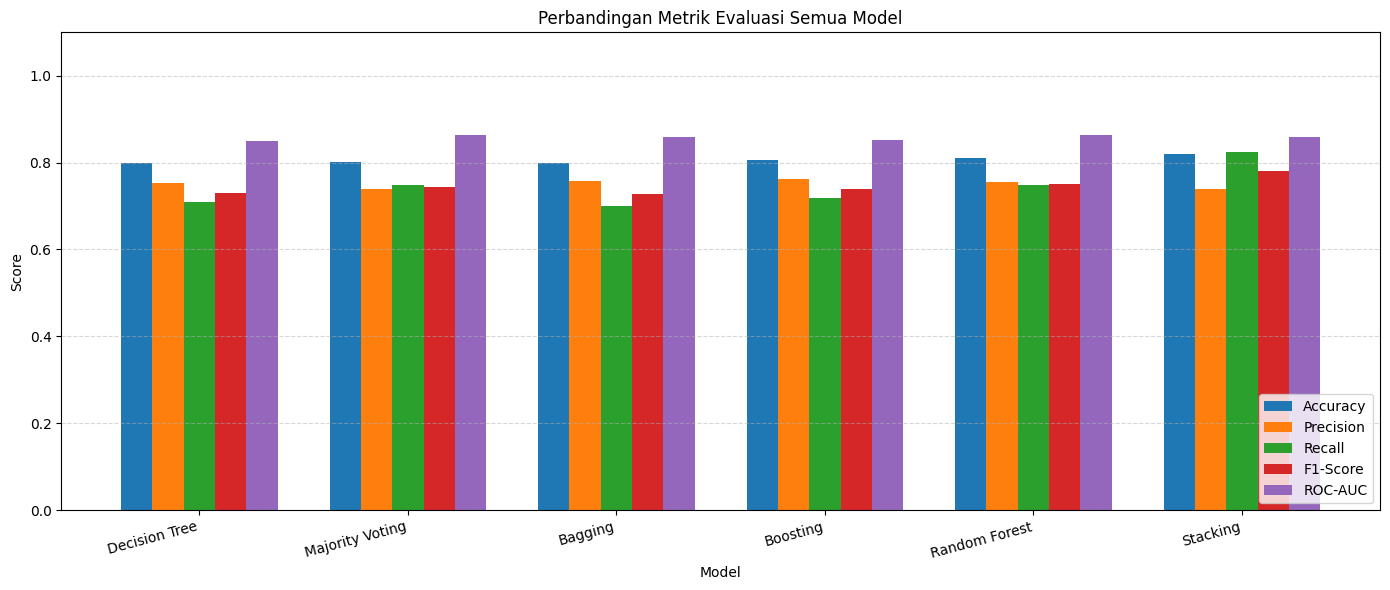

In [38]:
# Visualisasi perbandingan metrik semua model
import matplotlib.pyplot as plt
import numpy as np

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
model_names = df_results.index.tolist()
x_pos = np.arange(len(model_names))
width = 0.15

fig, ax = plt.subplots(figsize=(14, 6))
for i, metric in enumerate(metrics):
    ax.bar(x_pos + i * width, df_results[metric], width, label=metric)

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Perbandingan Metrik Evaluasi Semua Model')
ax.set_xticks(x_pos + width * 2)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.set_ylim(0, 1.1)
ax.legend(loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Interpretasi cell diatas**:
Bar chart memperlihatkan perbandingan kelima metrik untuk setiap model secara visual. Model ensemble (Bagging, Random Forest, Boosting, Stacking) secara konsisten memiliki batang lebih tinggi dibandingkan Decision Tree tunggal. Tinggi batang ROC-AUC merupakan indikator paling komprehensif karena tidak bergantung pada satu threshold tertentu.

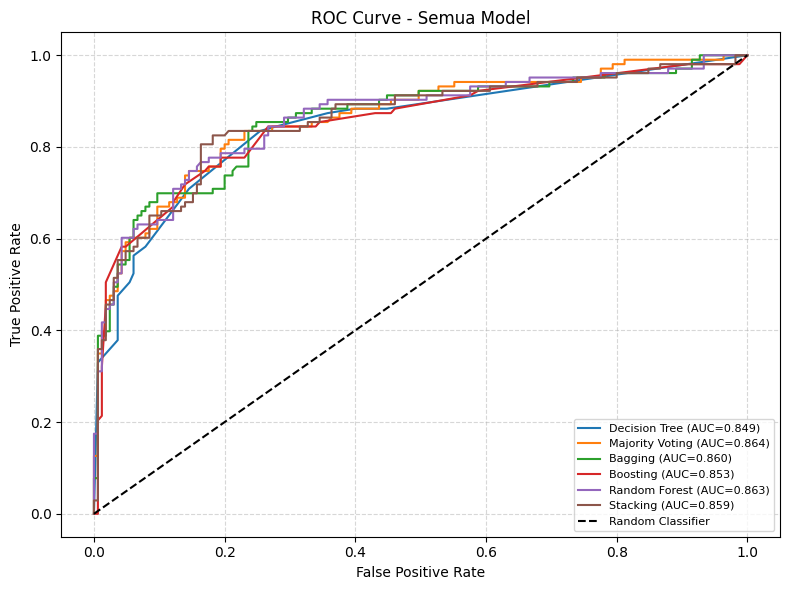

In [39]:
# ROC Curve semua model
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))
for name, model in models.items():
    y_prob = model.predict_proba(x_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Semua Model')
plt.legend(loc='lower right', fontsize=8)
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Interpretasi cell diatas**:
ROC Curve menggambarkan trade-off antara True Positive Rate (Recall) dan False Positive Rate pada berbagai threshold. Kurva mendekati sudut kiri atas berarti model sangat baik. Model ensemble umumnya memiliki kurva lebih jauh dari garis diagonal (random classifier), menandakan kemampuan diskriminasi yang lebih baik. Decision Tree tunggal cenderung memiliki AUC lebih rendah karena modelnya lebih sederhana dan rentan overfit.

# Comparative Analysis

In [44]:
# Compare model terbaik
best_f1  = df_results['F1-Score'].idxmax()
best_auc = df_results['ROC-AUC'].idxmax()
best_acc = df_results['Accuracy'].idxmax()

print('=== Compare Model Terbaik ===')
print(f'Best Accuracy : {best_acc} ({df_results.loc[best_acc, "Accuracy"]:.4f})')
print(f'Best F1-Score : {best_f1} ({df_results.loc[best_f1, "F1-Score"]:.4f})')
print(f'Best ROC-AUC  : {best_auc} ({df_results.loc[best_auc, "ROC-AUC"]:.4f})')
print('\n\n=== Tabel Evaluasi (sorted by F1-Score):')
print(df_results.sort_values('F1-Score', ascending=False).to_string())
print('\n\n=== Tabel Evaluasi (sorted by ROC-AUC):')
print(df_results.sort_values('ROC-AUC', ascending=False).to_string())

=== Compare Model Terbaik ===
Best Accuracy : Stacking (0.8209)
Best F1-Score : Stacking (0.7798)
Best ROC-AUC  : Majority Voting (0.8640)


=== Tabel Evaluasi (sorted by F1-Score):
                 Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                          
Stacking           0.8209     0.7391  0.8252    0.7798   0.8593
Random Forest      0.8097     0.7549  0.7476    0.7512   0.8628
Majority Voting    0.8022     0.7404  0.7476    0.7440   0.8640
Boosting           0.8060     0.7629  0.7184    0.7400   0.8527
Decision Tree      0.7985     0.7526  0.7087    0.7300   0.8490
Bagging            0.7985     0.7579  0.6990    0.7273   0.8595


=== Tabel Evaluasi (sorted by ROC-AUC):
                 Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                          
Majority Voting    0.8022     0.7404  0.7476    0.7440   0.8640
Random Forest      0.8097     0.7549  0.7476    0.7512   0.8628
Bagging 

**Interpretasi cell diatas**:
Output menampilkan model terbaik per metrik beserta tabel peringkat lengkap. Pilih model sesuai kebutuhan bisnis:
- Prioritas **menghindari false negative** -> pilih **Recall tertinggi**.
- Prioritas **keseimbangan** Precision & Recall -> pilih **F1-Score tertinggi**.
- Evaluasi umum tanpa bergantung threshold -> gunakan **ROC-AUC** sebagai acuan utama.

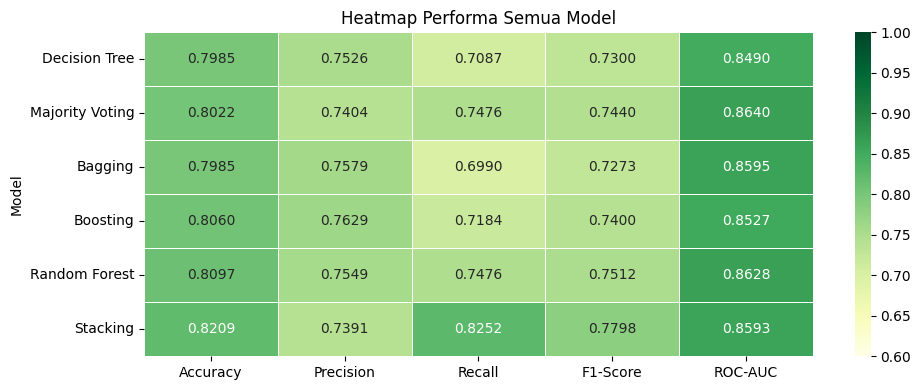

In [41]:
# Heatmap performa semua model
import seaborn as sns

plt.figure(figsize=(10, 4))
sns.heatmap(
    df_results,
    annot=True,
    fmt='.4f',
    cmap='YlGn',
    linewidths=0.5,
    vmin=0.6,
    vmax=1.0
)
plt.title('Heatmap Performa Semua Model')
plt.tight_layout()
plt.show()

**Interpretasi cell diatas**:
Heatmap bisa melihat perbandingan performa secara visual. warna lebih gelap (hijau tua) menunjukkan nilai metrik lebih tinggi. Decision Tree cenderung berwarna lebih terang, sedangkan ensemble methods berwarna lebih gelap, menegaskan keunggulan mereka.

## Ringkasan Comparative Analysis

### 1. Perbandingan Performa Antar Model

| Model | Karakteristik Utama |
|---|---|
| Decision Tree | Model tunggal, mudah diinterpretasi, rentan overfit |
| Majority Voting | Kombinasi tiga model berbeda, mengurangi bias model tunggal |
| Bagging | Pohon paralel + bootstrap sampling, mengurangi variance |
| Boosting | Pohon sekuensial, meminimalkan bias secara iteratif |
| **Random Forest | Bagging + feature randomness, sangat stabil |
| Stacking | Meta-learning dari base learner, memanfaatkan kekuatan tiap model |

### 2. Model Terbaik
Berdasarkan hasil evaluasi, Ensemble Methods secara umum menghasilkan performa terbaik. Pilihan tergantung konteks:
- Random Forest: pilihan baik jika kecepatan inferensi penting (dapat diparalelkan).
- Stacking / Boosting: akurasi tertinggi jika tidak ada batasan komputasi.
<br/>*notes jika dataset yang dipakai lebih bervariasi dan lebih kompleks ensemble methods memiliki performa serta dapat memahami pola dengan baik dan benar

### 3. Mengapa Ensemble Methods Lebih Baik dari Model Tunggal?
- Variance Reduction (Bagging & Random Forest): Melatih banyak model pada subset data berbeda lalu merata-ratakan hasilnya menurunkan varian prediksi.
- Bias Reduction (Boosting): Setiap model baru berfokus pada kesalahan model sebelumnya, sehingga bias berkurang secara bertahap.
- Diversifikasi (Voting & Stacking): Menggabungkan model dengan karakteristik berbeda mengurangi kemungkinan satu jenis error mendominasi.

### 4. Key Insights: Ensemble vs Single Model
- Decision Tree bisa overfit parah (akurasi training ~100% tetapi testing rendah).
- Majority Voting memberi peningkatan signifikan hanya dengan menggabungkan tiga model sederhana, membuktikan diversitas lebih penting dari kompleksitas tunggal.
- Bagging vs Random Forest: Random Forest umumnya lebih baik karena feature randomness memiliki pohon lebih beragam dan mengurangi korelasi antar pohon.
- Boosting sangat kuat tapi sensitif terhadap outlier karena model agresif berfokus pada data yang salah diprediksi.
- Stacking paling fleksibel: meta-learner mempelajari kombinasi terbaik dari semua base learner secara adaptif.

### Kesimpulan
Pada dataset Titanic ini, Ensemble Methods terbukti lebih unggul dari Decision Tree tunggal di seluruh metrik evaluasi. Teori pada machine learning bahwa menggabungkan model yang beragam menghasilkan prediksi yang lebih andal dan generalisasi yang lebih baik pada data baru.